Dataset Shape: (650, 22)
    age  gender marital_status education_level  annual_income  monthly_income  \
0  15.0  FEMALE            NaN          Master        76196.0             NaN   
1  16.0     NaN       Divorced          Master        23390.0         3934.17   
2  83.0  FEMALE            NaN          Master       232582.0        19381.83   
3  16.0    male        MARRIED         Diploma       157024.0             NaN   
4  69.0  FEMALE       Divorced          Master        75143.0         7258.92   

  employment_status  debt_to_income_ratio  credit_score  loan_amount  ...  \
0     Self-Employed                 29.71         878.0          NaN  ...   
1               NaN                 69.76         514.0     244715.0  ...   
2           Retired                 26.97         821.0      75341.0  ...   
3           Retired                112.23         277.0          NaN  ...   
4               NaN                   NaN         215.0      10071.0  ...   

  loan_term  installment 

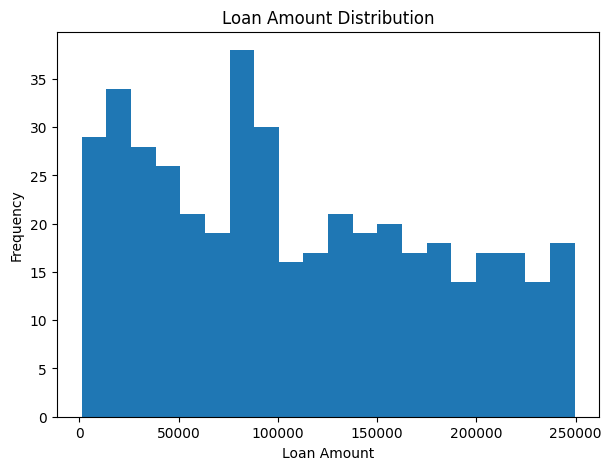

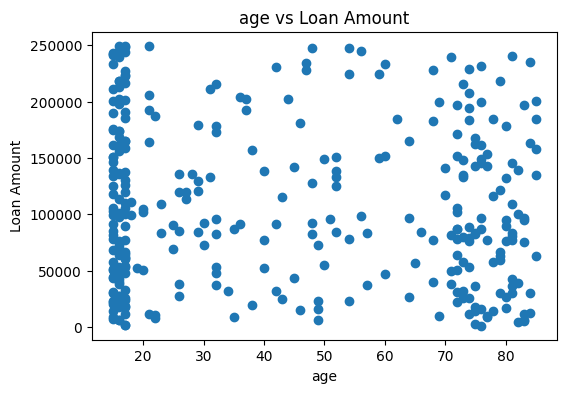

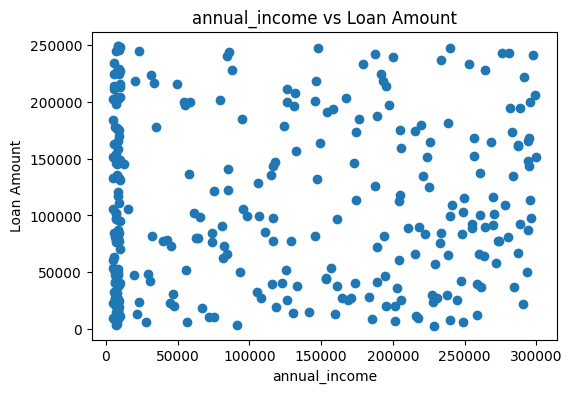

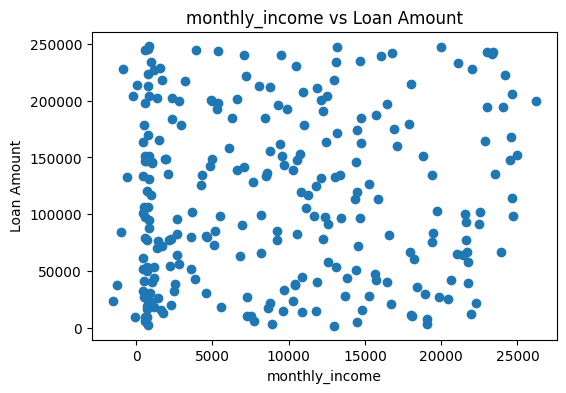

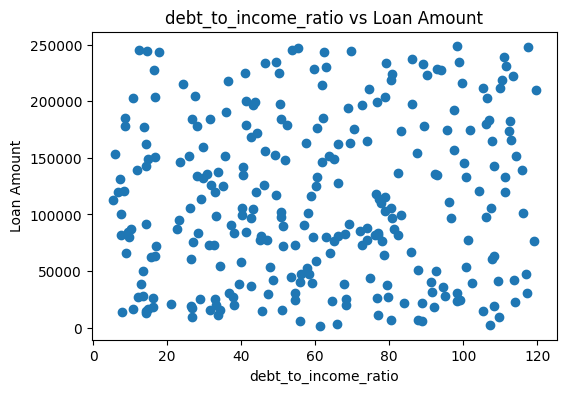

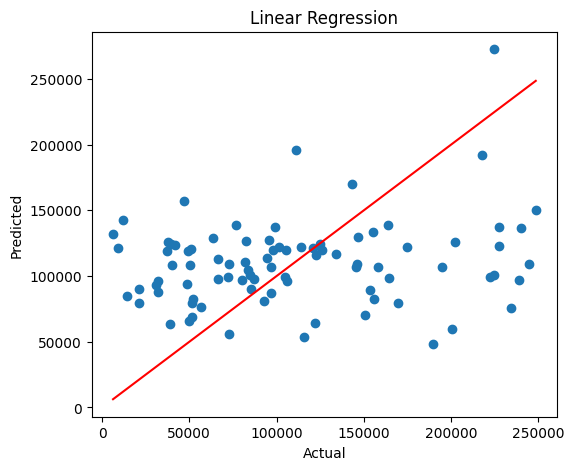

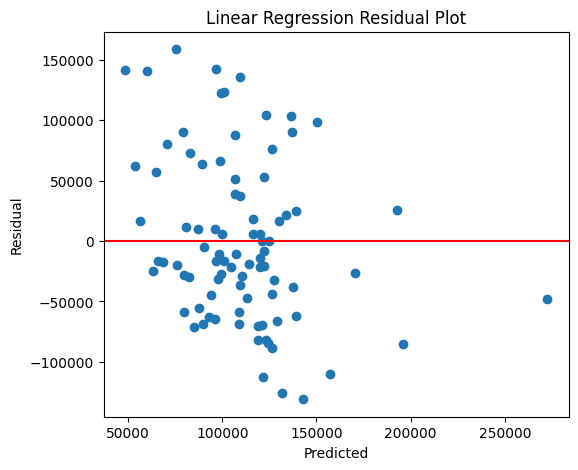

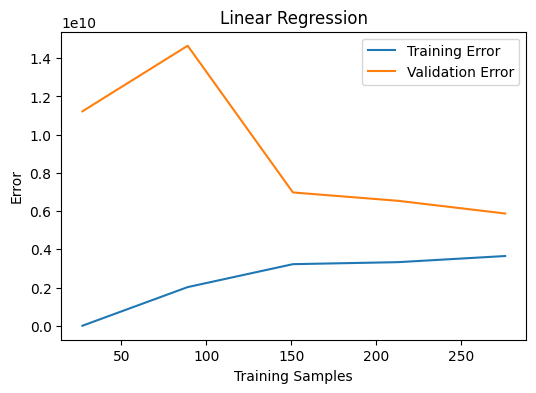


Ridge Regression
Best Parameters: {'model__alpha': 100}
Best CV Score: 0.08501711946977189


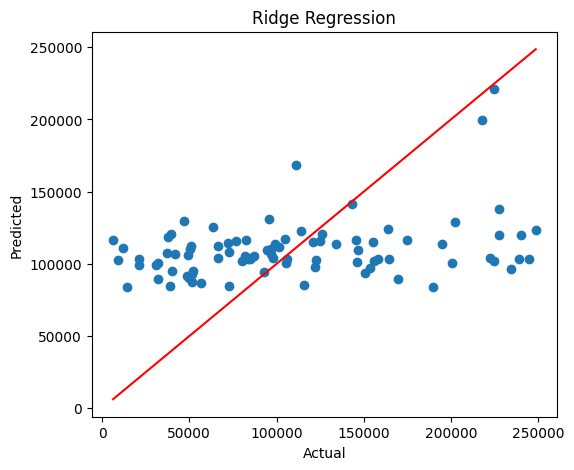

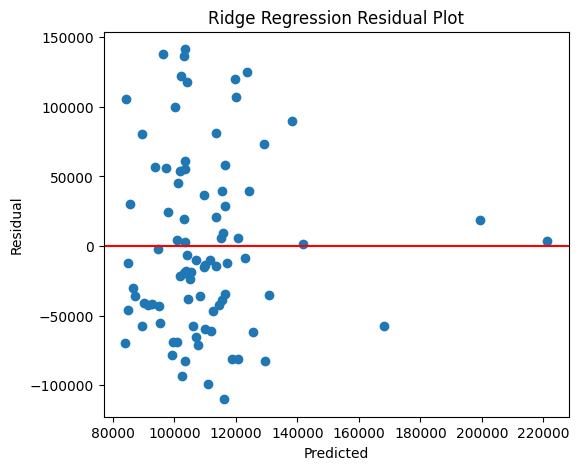

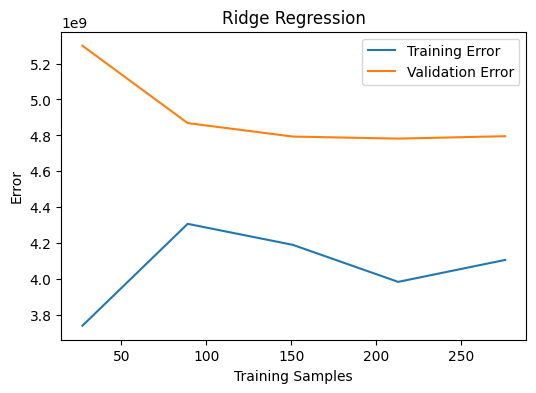


Lasso Regression
Best Parameters: {'model__alpha': 10}
Best CV Score: -0.12819810067889612


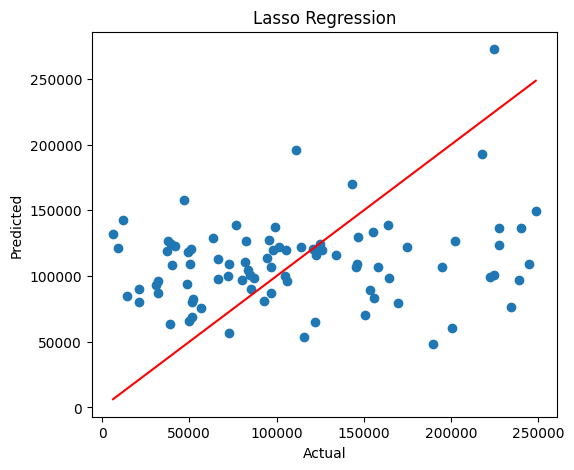

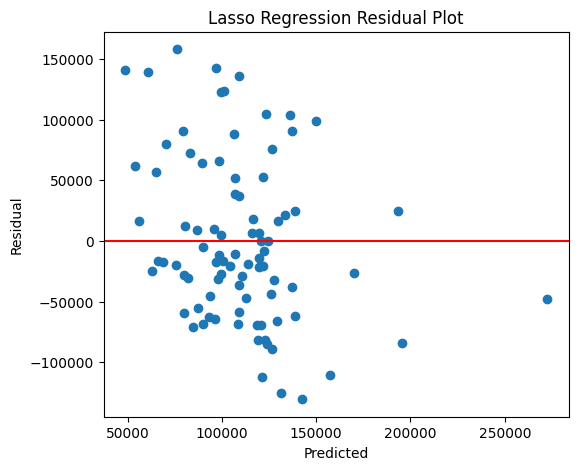

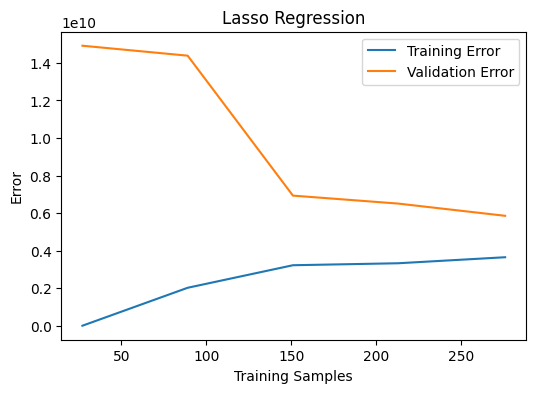


Elastic Net
Best Parameters: {'model__alpha': 1, 'model__l1_ratio': 0.5}
Best CV Score: 0.08598140389578665


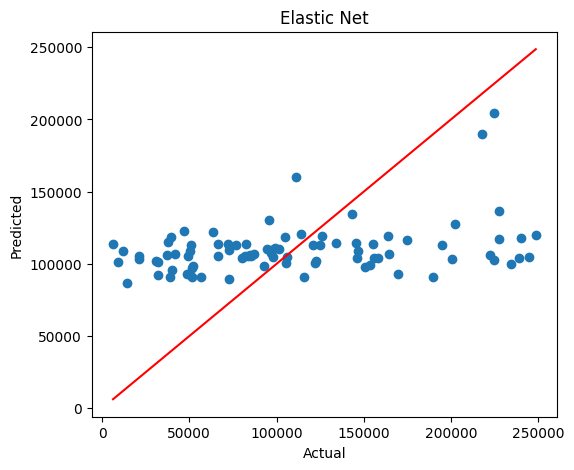

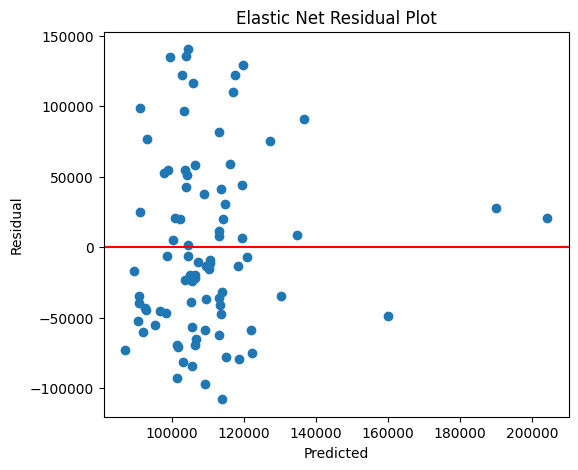

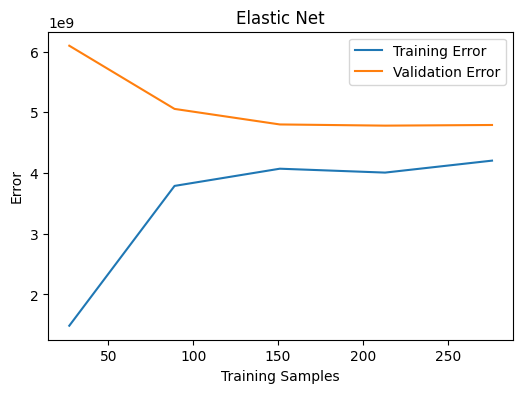


Performance Table
                            MAE           MSE          RMSE  R2 Score  \
Linear Regression  54649.599707  4.589702e+09  67747.337395 -0.045381   
Ridge Regression   51150.937315  3.927484e+09  62669.645398  0.105450   
Lasso Regression   54582.941268  4.576794e+09  67652.005016 -0.042441   
Elastic Net        51570.505372  3.903728e+09  62479.823751  0.110861   

                   Training Time  
Linear Regression       0.090682  
Ridge Regression        0.612354  
Lasso Regression        3.148245  
Elastic Net             1.457977  

Coefficient Table
                      Feature  Linear Regression  Ridge Regression  \
0                    num__age       -1780.615587      -1671.148448   
1          num__annual_income        2036.315073       1978.850352   
2         num__monthly_income        2969.575260       2446.705890   
3   num__debt_to_income_ratio        3534.683378       2858.204042   
4           num__credit_score        -324.900255        362.137880   
5

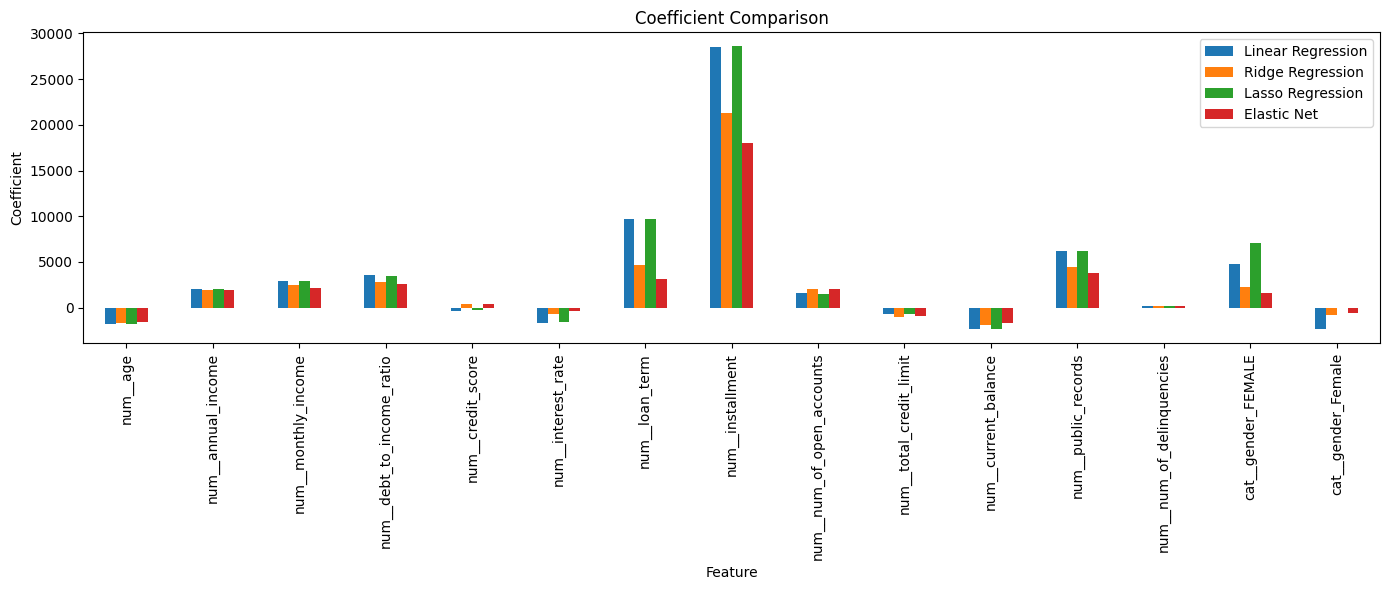


Experiment Completed Successfully.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    learning_curve
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

df = pd.read_csv("loan_amount_prediction_uncleaned_dataset(1).csv")

print("Dataset Shape:", df.shape)
print(df.head())


df = df.replace([np.inf, -np.inf], np.nan)

df = df.dropna(subset=["loan_amount"])

print("Dataset Shape after removing missing target:", df.shape)


X = df.drop("loan_amount", axis=1)
y = df["loan_amount"]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("\nNumerical Columns")
print(numeric_features)

print("\nCategorical Columns")
print(categorical_features)

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistics")
print(df.describe())

plt.figure(figsize=(7,5))
plt.hist(y, bins=20)
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

for col in numeric_features[:4]:

    plt.figure(figsize=(6,4))
    plt.scatter(df[col], y)
    plt.xlabel(col)
    plt.ylabel("Loan Amount")
    plt.title(f"{col} vs Loan Amount")
    plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

results = {}

trained_models = {}

def evaluate_model(model_name, model, param_grid=None):

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    if param_grid:

        search = GridSearchCV(
            pipeline,
            param_grid=param_grid,
            cv=5,
            scoring="r2",
            n_jobs=-1
        )

        start = time.time()
        search.fit(X_train, y_train)
        end = time.time()

        best_model = search.best_estimator_

        print("\n", "="*40)
        print(model_name)
        print("Best Parameters:", search.best_params_)
        print("Best CV Score:", search.best_score_)

    else:

        start = time.time()
        pipeline.fit(X_train, y_train)
        end = time.time()

        best_model = pipeline

    trained_models[model_name] = best_model

    train_time = end - start

    predictions = best_model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    mse = mean_squared_error(y_test, predictions)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, predictions)

    results[model_name] = [mae, mse, rmse, r2, train_time]

    plt.figure(figsize=(6,5))
    plt.scatter(y_test, predictions)

    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color='red'
    )

    plt.xlabel("Actual")

    plt.ylabel("Predicted")

    plt.title(model_name)

    plt.show()

    residuals = y_test - predictions

    plt.figure(figsize=(6,5))

    plt.scatter(predictions, residuals)

    plt.axhline(0, color='red')

    plt.xlabel("Predicted")

    plt.ylabel("Residual")

    plt.title(model_name + " Residual Plot")

    plt.show()

    train_sizes, train_scores, val_scores = learning_curve(

        best_model,

        X_train,

        y_train,

        cv=5,

        scoring="neg_mean_squared_error",

        n_jobs=-1

    )

    train_error = -train_scores.mean(axis=1)

    validation_error = -val_scores.mean(axis=1)

    plt.figure(figsize=(6,4))

    plt.plot(train_sizes, train_error, label="Training Error")

    plt.plot(train_sizes, validation_error, label="Validation Error")

    plt.xlabel("Training Samples")

    plt.ylabel("Error")

    plt.title(model_name)

    plt.legend()

    plt.show()

evaluate_model(
    "Linear Regression",
    LinearRegression()
)

evaluate_model(
    "Ridge Regression",
    Ridge(),
    {
        "model__alpha":[0.01,0.1,1,10,100]
    }
)

evaluate_model(
    "Lasso Regression",
    Lasso(max_iter=10000),
    {
        "model__alpha":[0.001,0.01,0.1,1,10]
    }
)

evaluate_model(
    "Elastic Net",
    ElasticNet(max_iter=10000),
    {
        "model__alpha":[0.01,0.1,1,10],
        "model__l1_ratio":[0.2,0.5,0.8]
    }
)

performance = pd.DataFrame(

    results,

    index=[
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score",
        "Training Time"
    ]

).T

print("\nPerformance Table")
print(performance)

coef_df = pd.DataFrame()

for name, model in trained_models.items():

    try:

        feature_names = model.named_steps["preprocessor"].get_feature_names_out()

        coefficients = model.named_steps["model"].coef_

        temp = pd.DataFrame({

            "Feature":feature_names,

            name:coefficients

        })

        if coef_df.empty:

            coef_df = temp

        else:

            coef_df = coef_df.merge(temp, on="Feature")

    except:

        pass

print("\nCoefficient Table")
print(coef_df.head(15))

coef_df.set_index("Feature").head(15).plot(

    kind="bar",

    figsize=(14,6)

)

plt.title("Coefficient Comparison")

plt.ylabel("Coefficient")

plt.tight_layout()

plt.show()

print("\nExperiment Completed Successfully.")